<a href="https://colab.research.google.com/github/Vansh-Rajderkar5901/OIBSIP/blob/main/VanshRajderkar_Project3Level1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("AB_NYC_2019.csv")
print("Original Dataset Shape:", df.shape)
df.head()

Original Dataset Shape: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])
print("\nColumn Names:")
print(df.columns)

Number of Rows: 48895
Number of Columns: 16

Column Names:
Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')


In [4]:
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage.round(2)
})
missing_table = missing_table[missing_table["Missing Values"] > 0]
missing_table

,Missing Values,Missing Percentage
name,16,0.03
host_name,21,0.04
last_review,10052,20.56
reviews_per_month,10052,20.56


In [5]:
df["name"] = df["name"].fillna("Unknown Listing")
df["host_name"] = df["host_name"].fillna("Unknown Host")
df["last_review"] = pd.to_datetime(df["last_review"], errors="coerce")
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [6]:
duplicate_count = df.duplicated().sum()
print("Duplicate Rows:", duplicate_count)

Duplicate Rows: 0


In [7]:
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (48895, 16)


In [8]:
text_columns = ["name", "host_name", "neighbourhood_group", "neighbourhood", "room_type"]
for col in text_columns:
    df[col] = df[col].astype(str).str.strip()
df[text_columns].head()

,name,host_name,neighbourhood_group,neighbourhood,room_type
0,Clean & quiet apt home by the park,John,Brooklyn,Kensington,Private room
1,Skylit Midtown Castle,Jennifer,Manhattan,Midtown,Entire home/apt
2,THE VILLAGE OF HARLEM....NEW YORK !,Elisabeth,Manhattan,Harlem,Private room
3,Cozy Entire Floor of Brownstone,LisaRoxanne,Brooklyn,Clinton Hill,Entire home/apt
4,Entire Apt: Spacious Studio/Loft by central park,Laura,Manhattan,East Harlem,Entire home/apt


In [9]:
print("Neighbourhood Groups:")
print(df["neighbourhood_group"].unique())
print("\nRoom Types:")
print(df["room_type"].unique())

Neighbourhood Groups:
['Brooklyn' 'Manhattan' 'Queens' 'Staten Island' 'Bronx']

Room Types:
['Private room' 'Entire home/apt' 'Shared room']


In [10]:
print("Number of unique neighbourhoods:", df["neighbourhood"].nunique())
print("Number of unique hosts:", df["host_id"].nunique())

Number of unique neighbourhoods: 221
Number of unique hosts: 37457


In [11]:
numeric_columns = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]

df[numeric_columns].describe()

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,152.720687,7.029962,23.274466,1.090910,7.143982,112.781327
std,240.154170,20.510550,44.550582,1.597283,32.952519,131.622289
min,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,69.000000,1.000000,1.000000,0.040000,1.000000,0.000000
50%,106.000000,3.000000,5.000000,0.370000,1.000000,45.000000
75%,175.000000,5.000000,24.000000,1.580000,2.000000,227.000000
max,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [12]:
print("Listings with price <= 0:", df[df["price"] <= 0].shape[0])
print("Listings with minimum nights <= 0:", df[df["minimum_nights"] <= 0].shape[0])
print("Listings with availability greater than 365:", df[df["availability_365"] > 365].shape[0])

Listings with price <= 0: 11
Listings with minimum nights <= 0: 0
Listings with availability greater than 365: 0


In [13]:
df = df[df["price"] > 0]

print("Shape after removing invalid price records:", df.shape)

Shape after removing invalid price records: (48884, 16)


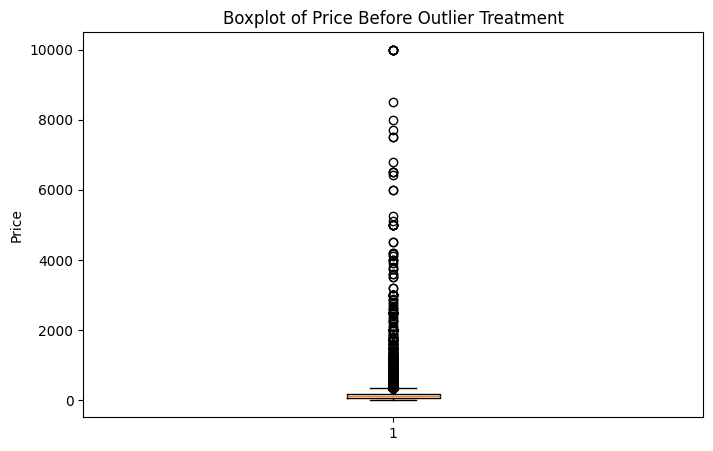

In [14]:
plt.figure(figsize=(8,5))
plt.boxplot(df["price"])
plt.title("Boxplot of Price Before Outlier Treatment")
plt.ylabel("Price")
plt.show()

In [15]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)
price_outliers = df[(df["price"] < lower_limit) | (df["price"] > upper_limit)]
print("Number of price outliers:", price_outliers.shape[0])

Lower Limit: -90.0
Upper Limit: 334.0
Number of price outliers: 2972


In [16]:
df_clean = df[(df["price"] >= lower_limit) & (df["price"] <= upper_limit)]
print("Original shape:", df.shape)
print("Clean shape after removing price outliers:", df_clean.shape)

Original shape: (48884, 16)
Clean shape after removing price outliers: (45912, 16)


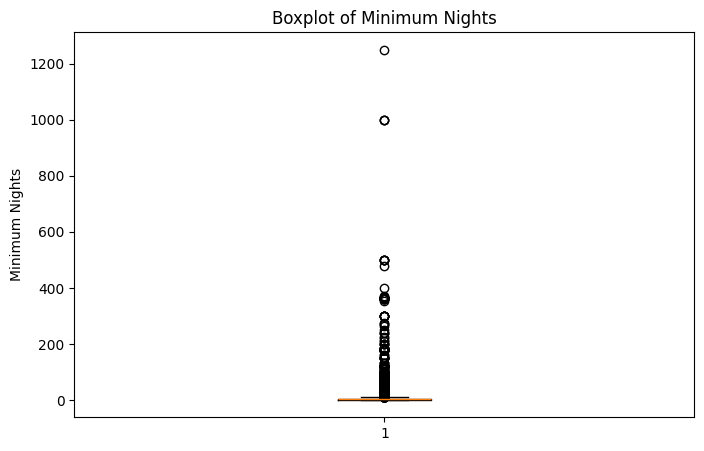

In [17]:
plt.figure(figsize=(8,5))
plt.boxplot(df_clean["minimum_nights"])
plt.title("Boxplot of Minimum Nights")
plt.ylabel("Minimum Nights")
plt.show()

In [18]:
df_clean["minimum_nights"].describe()

,minimum_nights
count,45912.000000
mean,6.937968
std,19.859505
min,1.000000
25%,1.000000
50%,2.000000
75%,5.000000
max,1250.000000


In [19]:
df_clean = df_clean[df_clean["minimum_nights"] <= 365]
print("Shape after cleaning minimum nights:", df_clean.shape)

Shape after cleaning minimum nights: (45899, 16)


In [20]:
print("Missing values in final dataset:")
print(df_clean.isnull().sum())

Missing values in final dataset:
id                                   0
name                                 0
host_id                              0
host_name                            0
neighbourhood_group                  0
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                                0
minimum_nights                       0
number_of_reviews                    0
last_review                       9004
reviews_per_month                    0
calculated_host_listings_count       0
availability_365                     0
dtype: int64


In [21]:
df_clean["id"] = df_clean["id"].astype(int)
df_clean["host_id"] = df_clean["host_id"].astype(int)
df_clean["price"] = df_clean["price"].astype(float)
df_clean["minimum_nights"] = df_clean["minimum_nights"].astype(int)
df_clean["number_of_reviews"] = df_clean["number_of_reviews"].astype(int)
df_clean["availability_365"] = df_clean["availability_365"].astype(int)
df_clean.dtypes

,0
id,int64
name,object
host_id,int64
host_name,object
neighbourhood_group,object
neighbourhood,object
latitude,float64
longitude,float64
room_type,object
price,float64


In [22]:
df_clean["has_reviews"] = df_clean["number_of_reviews"].apply(lambda x: "Yes" if x > 0 else "No")
df_clean["price_category"] = pd.cut(
    df_clean["price"],
    bins=[0, 50, 150, 300, 1000],
    labels=["Budget", "Mid-Range", "Premium", "Luxury"]
)
df_clean[["price", "price_category", "has_reviews"]].head()

,price,price_category,has_reviews
0,149.0,Mid-Range,Yes
1,225.0,Premium,Yes
2,150.0,Mid-Range,No
3,89.0,Mid-Range,Yes
4,80.0,Mid-Range,Yes


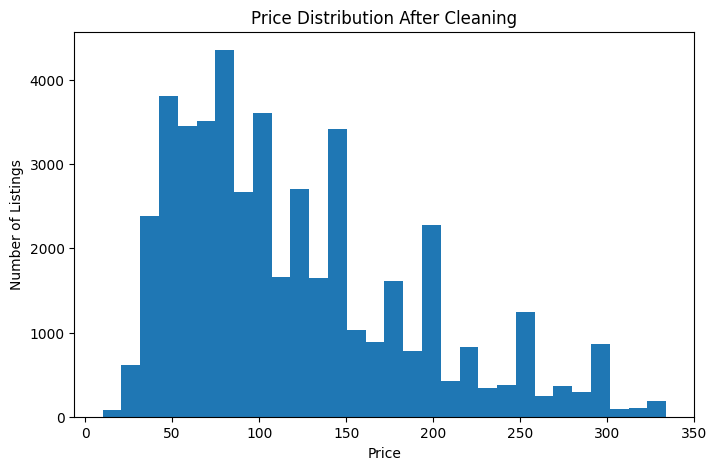

In [23]:
plt.figure(figsize=(8,5))
plt.hist(df_clean["price"], bins=30)
plt.title("Price Distribution After Cleaning")
plt.xlabel("Price")
plt.ylabel("Number of Listings")
plt.show()

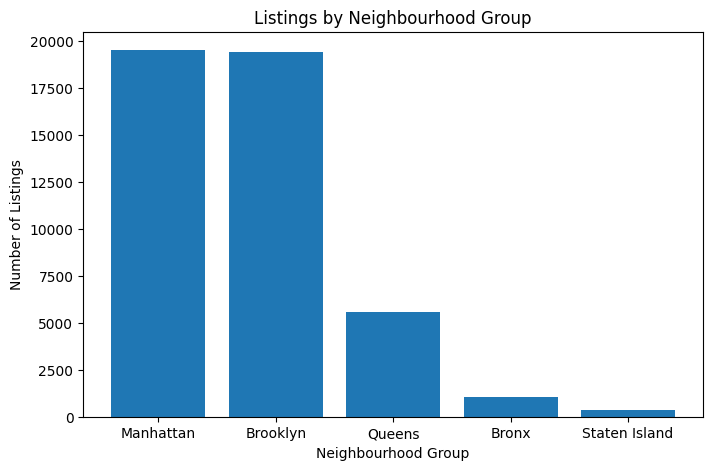

In [24]:
neighbourhood_count = df_clean["neighbourhood_group"].value_counts()

plt.figure(figsize=(8,5))
plt.bar(neighbourhood_count.index, neighbourhood_count.values)
plt.title("Listings by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Number of Listings")
plt.show()

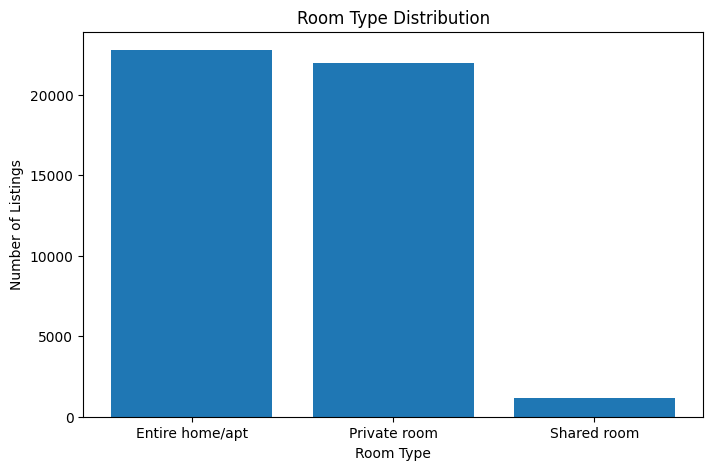

In [25]:
room_type_count = df_clean["room_type"].value_counts()
plt.figure(figsize=(8,5))
plt.bar(room_type_count.index, room_type_count.values)
plt.title("Room Type Distribution")
plt.xlabel("Room Type")
plt.ylabel("Number of Listings")
plt.show()

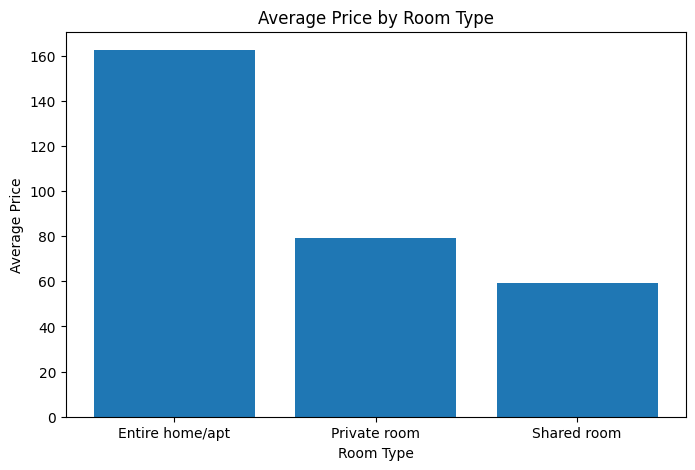

In [26]:
avg_price_room = df_clean.groupby("room_type")["price"].mean().sort_values(ascending=False)
plt.figure(figsize=(8,5))
plt.bar(avg_price_room.index, avg_price_room.values)
plt.title("Average Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Average Price")
plt.show()

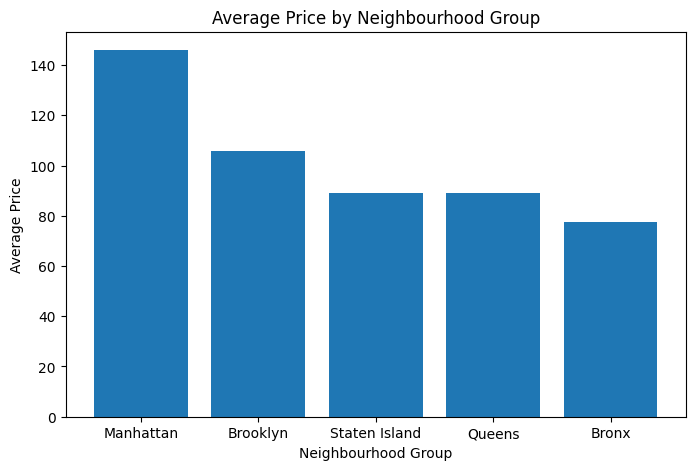

In [27]:
avg_price_area = df_clean.groupby("neighbourhood_group")["price"].mean().sort_values(ascending=False)
plt.figure(figsize=(8,5))
plt.bar(avg_price_area.index, avg_price_area.values)
plt.title("Average Price by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Average Price")
plt.show()

In [28]:
cleaning_summary = pd.DataFrame({
    "Stage": ["Original Dataset", "After Cleaning"],
    "Rows": [48895, df_clean.shape[0]],
    "Columns": [16, df_clean.shape[1]]
})
cleaning_summary

,Stage,Rows,Columns
0,Original Dataset,48895,16
1,After Cleaning,45899,18


In [29]:
print("Original rows:", 48895)
print("Final cleaned rows:", df_clean.shape[0])
print("Rows removed:", 48895 - df_clean.shape[0])

Original rows: 48895
Final cleaned rows: 45899
Rows removed: 2996


In [30]:
df_clean.to_csv("cleaned_AB_NYC_2019.csv", index=False)
print("Cleaned dataset saved successfully as cleaned_AB_NYC_2019.csv")

Cleaned dataset saved successfully as cleaned_AB_NYC_2019.csv
